In [1]:
#Using suggestion from Post#270 where i ran the sentence transformer first and it works

from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

In [2]:
# Initialize Otter
import otter
grader = otter.Notebook("hw6.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 6: Clustering
### Associated lectures: [Lectures 14 and 15](https://ubc-cs.github.io/cpsc330-2025W2/#lecture-schedule-tentative)

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2025W2/#deliverable-due-dates-tentative)**.

## Imports <a name="im"></a>

In [3]:
import os
from hashlib import sha1

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
pd.set_option("display.max_colwidth", 0)

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Group wotk instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   


### General submission instructions

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
  
- **Submit your files on Gradescope.**  
   - Upload only your `.ipynb` file **with outputs displayed** and any required output files.
     
   - Do **not** submit other files from your repository.  
   - If you need help, see the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- **Check that outputs render properly.**  
   - Make sure all plots and outputs appear in your submission.
     
   - If your `.ipynb` file is too large and doesn't render on Gradescope, also upload a PDF version so the TAs can view your work.
- **Keep execution order clean.**  
   - Execution numbers must start at "1" and increase in order.
     
   - Notebooks without visible outputs may not be graded.  
   - Out-of-order or missing execution numbers may result in mark deductions.  
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 
   
</div>

_Points:_ 4

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 1: Document clustering warm-up
<hr>

In this homework, we will explore a popular application of clustering called [**document clustering**](https://en.wikipedia.org/wiki/Document_clustering). A large amount of unlabeled text data is available out there (e.g., news, recipes, online Q&A, tweets), and clustering is a commonly used technique to organize this data in a meaningful way. 

As a warm up, in this exercise you will cluster sentences from a toy corpus. Later in the homework you will work with a real corpus. 

The code below extracts introductory sentences of Wikipedia articles on a set of queries. To run the code successfully, you will need the `wikipedia` package installed in the course environment. 

```
conda activate cpsc330
conda install -c conda-forge wikipedia
```


**Your tasks:**

Run the code below which 
- extracts content of Wikipedia articles on a set of queries
- tokenizes the text (i.e., separates sentences) and 
- stores the 2nd sentence in each article as a document representing that article

> Feel free to experiment with Wikipedia queries of your choice. But stick to the provided list for the final submission so that it's easier for the TAs to grade your submission.

> For tokenization we are using the `nltk` package. If you do not have this package in the course environment, you will have to install it.

```
conda activate cpsc330
conda install -c anaconda nltk
```

Even if you have the package installed via the course `conda` environment, you might have to download `nltk` pre-trained models, which can be done with the code below.

In [4]:
import nltk

nltk.download("punkt")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\matth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\matth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [5]:
import wikipedia
import string
from nltk.tokenize import sent_tokenize, word_tokenize

queries = [
    "Artificial Intelligence",
    "Deep learning",
    "Unsupervised learning",
    "Quantum Computer",
    "Environmental protection",
    "Climate Change",
    "Renewable Energy",
    "Biodiversity",
    "French Cuisine",
    "Bread food",
    "Dumpling food",
]
wiki_dict = {"wiki query": [], "text": [], "n_words": []}
remove_tokens = list(string.punctuation) + ['``', '’', '`', 'br', '"', "”", "''", "'s", "(", ")", "[", "]"]

# Running this code might take some time.
for query in queries:
    try:
        # Attempt to fetch the page content
        page_content = wikipedia.page(query).content
    except wikipedia.exceptions.PageError:
        print(f"Page not found for query: {query}. Skipping...")
        continue
    except wikipedia.exceptions.DisambiguationError as e:
        print(f"Query: {query} led to a disambiguation page. Choosing the first option: {e.options[0]}")
        page_content = wikipedia.page(e.options[0]).content

    text = sent_tokenize(page_content)[0]
    tokenized = word_tokenize(text)
    text_pp = [token.lower() for token in tokenized if token.lower() not in remove_tokens]
    wiki_dict["n_words"].append(len(text_pp))
    wiki_dict["text"].append(" ".join(text_pp))
    wiki_dict["wiki query"].append(query)

wiki_df = pd.DataFrame(wiki_dict)
wiki_df

,wiki query,text,n_words
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20
7,Biodiversity,biodiversity is the variability of life on earth,8
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10
9,Bread food,bread is a baked food product made from water flour and often yeast,13


Our toy corpus has six toy documents (`text` column in the dataframe) extracted from Wikipedia queries. 

<br><br>

<!-- BEGIN QUESTION -->

### 1.1 How many clusters? 
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

- If tasked with manually clustering documents from this toy corpus, how many clusters would you identify, and what labels would you assign to each cluster?
</div>

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 1

There are 3 clusters. A category for Artificial Intelligence, Deep learning, Quantum Computer and Unsupervised learning would have a label name of "Information technology". A category for Environment protection, Climate Change, Renewable energy and Biodiversity would have a label name of "Climate". A category for French Cuisine, Bread food and Dumpling food would have a label name of "Food".

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.2 K-Means with bag-of-words representation 
rubric={accuracy}

In the lecture, we explored how **data representation significantly impacts clustering quality**. We saw that replacing a **flattened image representation** with feature vectors extracted from **pre-trained models** greatly improved clustering results.  

What about text data? In previous machine learning courses, we have used the **bag-of-words (BoW) representation** to numerically encode text, where each document is represented with a vector of word frequencies. 

In this exercise, you will **cluster documents** using this **simplistic text representation**.  

<div class="alert alert-info">

**Your tasks:**

1. Use [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) with its **default settings** to transform the `text` column in `wiki_df` into a numerical representation.  

2. Use [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) to cluster the encoded documents and store the cluster labels in `kmeans_bow_labels`.  
   - Set `random_state=42` for **reproducibility**.
     
   - Use the **number of clusters** (`n_clusters`) identified in the **previous exercise**.  
</div>

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 2

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

CountVec = CountVectorizer()
X = CountVec.fit_transform(wiki_df['text'])
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [7]:
kmeans_bow_labels = kmeans.predict(X)

In [8]:
wiki_df["bow_kmeans"] = kmeans_bow_labels
wiki_df

,wiki query,text,n_words,bow_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1
7,Biodiversity,biodiversity is the variability of life on earth,8,1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 K-Means with sentence embedding representation
rubric={accuracy}

In the previous exercise, you may have noticed that clustering results were suboptimal. While the bag-of-words (BoW) representation is useful, it has significant limitations. It does not capture word order or context effectively.  

To improve text representation, we can use pre-trained models, similar to those used for image data, to extract richer, context-aware embeddings through transfer learning. In this lab, we will use the **pre-trained model** `'all-MiniLM-L6-v2'`, available via the [Sentence Transformers](https://www.sbert.net/index.html) package.  

This deep learning model generates **dense, fixed-length vector representations** of sentences, capturing **semantic meaning and contextual information**. These representations are particularly effective for **clustering and semantic similarity tasks**. If you're interested in exploring more **pre-trained models**, refer to the [full list here](https://www.sbert.net/docs/pretrained_models.html). We will explore these representations further in **DSCI 575**.  

<div class="alert alert-info">

**Your tasks:**

1. Run the code below to create sentence embedding representation of documents in our toy corpus.
   
3. Apply `KMeans` to the **sentence embeddings** (`emb_sents`) and store the cluster labels in `kmeans_emb_labels`. Use the following parameters:  
    - `random_state=42` (for reproducibility)
      
    - `n_clusters`=the number of clusters you identified in 1.1

Note
- The code below might throw a warning. You may ignore it for the purpose of this lab. 
</div>

In [9]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

In [10]:
emb_sents = embedder.encode(wiki_df["text"].tolist())
emb_sent_df = pd.DataFrame(emb_sents, index=wiki_df.index)
emb_sent_df

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.005857,-0.004795,-0.000976,0.011121,0.005294,-0.061630,0.062072,0.033673,-0.035251,0.074072,...,0.088312,-0.006600,0.036511,-0.020797,-0.002082,0.058263,0.061880,0.097383,0.058155,-0.052016
1,-0.122905,-0.092450,0.085379,-0.009761,0.001422,0.069145,-0.046654,-0.069960,-0.021858,-0.052803,...,0.065826,0.031800,-0.021052,-0.113772,-0.013588,0.056793,-0.013167,0.009044,-0.011912,-0.011387
2,-0.056721,-0.049697,-0.014780,0.022572,0.051773,0.007456,0.008632,-0.074847,-0.065573,-0.027284,...,0.014761,-0.022392,0.021360,-0.107016,0.020530,0.045678,0.052755,0.005429,0.022018,-0.010994
3,-0.071932,-0.006760,-0.083421,0.022650,-0.116415,0.034988,-0.055792,-0.045055,-0.017993,0.020915,...,-0.076031,-0.016973,-0.054588,-0.020448,-0.016833,0.120573,0.027863,0.076044,0.060111,0.057609
4,-0.012700,0.101830,0.066676,-0.007987,0.140040,0.041627,0.035495,-0.050723,-0.037633,0.055886,...,-0.042105,-0.038883,0.018268,0.009920,0.028208,0.052759,-0.009605,-0.004518,0.060853,0.057709
5,-0.014444,0.022869,0.145982,0.054865,0.085204,-0.014689,-0.102757,0.016853,-0.023799,0.021148,...,0.011778,0.016817,-0.020041,0.006375,0.055428,0.076868,-0.047152,-0.114797,-0.056382,0.022349
6,-0.044869,0.076882,-0.012749,0.033335,0.067894,-0.002327,0.031620,-0.021576,0.046619,0.005089,...,-0.021575,-0.017596,-0.069995,0.004461,-0.040409,-0.043067,0.044042,-0.050977,0.056506,0.048708
7,0.027806,0.077117,0.015402,-0.013544,0.043216,0.048124,0.027763,-0.022999,0.049303,0.009686,...,0.014946,-0.020896,0.022283,-0.012311,0.014079,0.028085,0.025272,-0.015233,-0.014879,-0.064280
8,0.026616,-0.019929,-0.008049,-0.025907,-0.055372,0.011235,-0.024538,-0.065724,0.058374,-0.062895,...,-0.059513,0.077446,-0.059827,-0.021454,0.088102,-0.127180,-0.031399,0.120572,0.072373,-0.058336
9,-0.014786,0.055887,-0.020880,0.005313,-0.025037,0.040479,0.035260,0.024938,0.017546,0.072433,...,-0.082098,0.037856,-0.020007,-0.087252,0.058163,-0.044187,-0.030253,-0.080385,0.075614,-0.070403


<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 2

In [11]:
kmeans_emb = KMeans(n_clusters=3,random_state=111)
kmeans_emb.fit(emb_sents)

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [12]:
kmeans_emb_labels = kmeans_emb.predict(emb_sents)

In [13]:
wiki_df["emb_kmeans"] = kmeans_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1,0
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.4 DBSCAN with sentence embedding representation and cosine distance  
rubric={accuracy}

Now, let's apply [`DBSCAN`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) to our toy dataset.  

Unlike K-Means, which relies on Euclidean distance due to its use of centroids, DBSCAN allows us to experiment with different distance metrics. For text data, [**cosine similarity**](https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity) (or its complement, **cosine distance**) is often more effective than Euclidean distance.  

The **cosine distance** between two vectors $u$ and $v$ is defined as: 

$$distance_{cosine}(u,v) = 1 - (\frac{u \cdot v}{\left\lVert u\right\rVert_2 \left\lVert v\right\rVert_2})$$

<div class="alert alert-info">

**Your tasks:**

- Apply **DBSCAN** to cluster documents encoded with **sentence embeddings** (`emb_sents`) and store the cluster labels in `dbscan_emb_labels`.
    
- Set `metric='cosine'` to use **cosine distance** for clustering.
- Tune the **hyperparameters** `eps` and `min_samples` to obtain meaningful clusters, as the default values are unlikely to work well on this dataset.  

**Notes for tuning the hyperparameters:**

- Start by examining the minimum, maximum, and mean cosine distances in the dataset. You can compute pairwise cosine distances using the package imported below.
  
- Experiment with a range of `eps` values and print the number of clusters and their sizes for each value.
- Select the `eps` value that produces the desired number of clusters.


</div>

In [14]:
from sklearn.metrics.pairwise import cosine_distances

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

In [15]:
from sklearn.cluster import DBSCAN

In [16]:
eps = np.linspace(0.1,1,num=10)
min_sams = np.arange(1,10)

cos_dist = cosine_distances(X)
cos_dist_mean = cos_dist.mean()
cos_dist_min = cos_dist.min()
cos_dist_max = cos_dist.max()
print(cos_dist_mean,cos_dist_max,cos_dist_min)

for e in eps:
    for m in min_sams:
        dbs = DBSCAN(eps=e,min_samples=m,n_jobs=-1,metric='cosine')
        preds = dbs.fit_predict(emb_sents)
        vals = np.unique(preds)
        print(e,m,len(vals))

0.7879658480769433 0.9648635815536847 0.0
0.1 1 11
0.1 2 1
0.1 3 1
0.1 4 1
0.1 5 1
0.1 6 1
0.1 7 1
0.1 8 1
0.1 9 1
0.2 1 11
0.2 2 1
0.2 3 1
0.2 4 1
0.2 5 1
0.2 6 1
0.2 7 1
0.2 8 1
0.2 9 1
0.30000000000000004 1 11
0.30000000000000004 2 1
0.30000000000000004 3 1
0.30000000000000004 4 1
0.30000000000000004 5 1
0.30000000000000004 6 1
0.30000000000000004 7 1
0.30000000000000004 8 1
0.30000000000000004 9 1
0.4 1 11
0.4 2 1
0.4 3 1
0.4 4 1
0.4 5 1
0.4 6 1
0.4 7 1
0.4 8 1
0.4 9 1
0.5 1 11
0.5 2 1
0.5 3 1
0.5 4 1
0.5 5 1
0.5 6 1
0.5 7 1
0.5 8 1
0.5 9 1
0.6 1 9
0.6 2 2
0.6 3 2
0.6 4 1
0.6 5 1
0.6 6 1
0.6 7 1
0.6 8 1
0.6 9 1
0.7000000000000001 1 6
0.7000000000000001 2 3
0.7000000000000001 3 3
0.7000000000000001 4 2
0.7000000000000001 5 1
0.7000000000000001 6 1
0.7000000000000001 7 1
0.7000000000000001 8 1
0.7000000000000001 9 1
0.8 1 3
0.8 2 3
0.8 3 3
0.8 4 3
0.8 5 1
0.8 6 1
0.8 7 1
0.8 8 1
0.8 9 1
0.9 1 1
0.9 2 1
0.9 3 1
0.9 4 2
0.9 5 2
0.9 6 2
0.9 7 1
0.9 8 1
0.9 9 1
1.0 1 1
1.0 2 1
1.0 3 1
1.

In [17]:
final_dbs = DBSCAN(eps=cos_dist_mean,min_samples=2,n_jobs=-1,metric='cosine')
final_preds = final_dbs.fit_predict(emb_sents)
final_vals = np.unique(final_preds)
print(cos_dist_mean,2,len(final_vals))

0.7879658480769433 2 3


In [18]:
dbscan_emb_labels = final_preds

In [19]:
wiki_df["emb_dbscan"] = dbscan_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,0
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,0
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,0
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2,0
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,1
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,1
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1,0,1
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,1
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,2
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,2


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.5 Hierarchical clustering with sentence embedding representation
rubric={accuracy}

<div class="alert alert-info">

**Your tasks:**

Apply hierarchical clustering on `emb_sents`. In particular
1. Create and show a dendrogram with `complete` linkage and `metric='cosine'` on this toy dataset.

3. Create flat clusters using `fcluster` with appropriate hyperparameters and store cluster labels to `hier_emb_labels` variable below.

</div>

<div class="alert alert-warning">

Solution_1.5
    
</div>

_Points:_ 3

In [20]:
from scipy.cluster.hierarchy import single,average,complete,dendrogram,ward,fcluster,linkage

Text(0.5, 1.0, 'Complete linkage of data set')

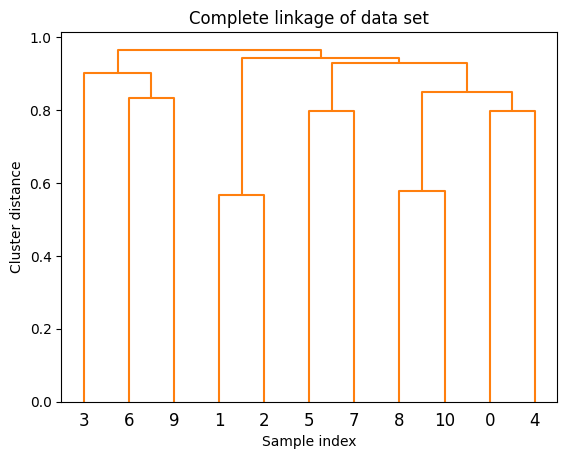

In [21]:
# Plotting of dendrogram referenced from lecture 15

comp_arr = linkage(X.toarray(),method="complete",metric="cosine")

ax = plt.gca()
dendrogram(comp_arr,ax=ax,color_threshold=2)
plt.xlabel("Sample index")
plt.ylabel("Cluster distance")
plt.title("Complete linkage of data set")

In [22]:
hier_emb_labels = fcluster(ward(X.toarray()),3,criterion="maxclust")

In [23]:
wiki_df["emb_hierarchical"] = hier_emb_labels
wiki_df

,wiki query,text,n_words,bow_kmeans,emb_kmeans,emb_dbscan,emb_hierarchical
0,Artificial Intelligence,artificial intelligence ai is the capability of computational systems to perform tasks typically associated with human intelligence such as learning reasoning problem-solving perception and decision-making,25,1,2,0,1
1,Deep learning,in machine learning deep learning dl focuses on utilizing multilayered neural networks to perform tasks such as classification regression and representation learning,22,2,2,0,1
2,Unsupervised learning,in machine learning supervised learning sl is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example input-output pairs,30,2,2,0,1
3,Quantum Computer,a quantum computer is a real or theoretical computer that exploits superposed and entangled states,15,1,2,0,2
4,Environmental protection,environmental protection or environment protection refers to the taking of measures to protecting the natural environment prevent pollution and maintain ecological balance,22,0,0,1,2
5,Climate Change,present-day climate change includes both global warming — the ongoing increase in global average temperature — and its wider effects on earth climate system,24,1,0,1,2
6,Renewable Energy,renewable energy also called green energy is energy made from renewable natural resources that are replenished on a human timescale,20,1,0,1,2
7,Biodiversity,biodiversity is the variability of life on earth,8,1,0,1,2
8,French Cuisine,french cuisine is the cooking traditions and practices of france,10,1,1,2,2
9,Bread food,bread is a baked food product made from water flour and often yeast,13,1,1,2,2


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.6 Discussion
rubric={reasoning}

<div class="alert alert-info">

**Your tasks:**

Reflect on and discuss the clustering results of the methods you explored in the previous exercises, focusing on the following points:    
- effect of input representation on clustering results

- whether the clustering results match with your intuitions and the challenges associated with getting the desired clustering results with each method

</div>

<div class="alert alert-warning">

Solution_1.6
    
</div>

_Points:_ 4

From using KMeans model, I was able to observe the difference in using CountVectorizer and Sentence Transformer. CountVectorizer wasn't able to accurately represent the examples into meaningful cluster, while Sentence Transformer did. It was also relatively easy to manipulate the number of clusters by simply adjusting the ```n_clusters``` parameter.

Continuing with the Sentence Transform data set, DBScan was able to accurately cluster the samples aorund meaningful clusters as well. Although it had more parameters to adjust with such as ```eps``` and ```min_samples```, these adjustments are able to make meaningful clusters on the data set, making the correct adjustments requires fine tuning the hyperparameters.

For hierarchical, one can select between the many methods to cluster the samples. This allows one to decide a method that fits the best clustering representation to the data set. However, one cannot fine tune the model to make better clusters and could only limit the number of clusters that can be use to represent the data set.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.7 Visualizing clusters
rubric={points:4}


One approach to working with unlabeled data is visualization. That said, our data is high-dimensional, making it challenging to visualize. Take sentence embedding representation as an example: each instance is depicted in 768 dimensions. To visualize such high-dimensional data, we can employ dimensionality reduction techniques to extract the most significant 2 or 3 components, and then visualize this low-dimensional data.

Given data as a `numpy` array and corresponding cluster assignments, the `plot_umap_clusters` function below transforms the data by applying dimensionality reduction technique called [UMAP](https://umap-learn.readthedocs.io/en/latest/) to it and plots the transformed data with different colours for different clusters. 

> *Note: At this point we are using this function only for visualization and you are not expected to understand the UMAP part.* 

You'll have to install the `umap-learn` package in the course conda environment either with `conda` or `pip`, as described in the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html). 

```
> conda activate cpsc330
> conda install -c conda-forge umap-learn
```
or

```
> conda activate cpsc330
> pip install umap-learn 
```

If you get an error with the import below try

```
pip install --upgrade numba umap-learn
```

<div class="alert alert-info">
    
**Your tasks:**

1. Visualize the clusters created by the methods above using `plot_umap_clusters` function below. In other words, visualize clusters identified by each of the methods below. 
    - K-Means with bag-of-words representation 
    - K-Means with sentence embedding representation
    - DBSCAN with sentence embedding representation 
    - Flat cluster of hierarchical clustering with sentence embedding representation
</div>

In [24]:
import umap

In [25]:
def plot_umap_clusters(
    data,
    cluster_labels,
    raw_texts=None,
    show_labels=False,
    point_size=50,
    n_neighbors=15,
    title="UMAP Visualization",
    ignore_noise=False,
):
    """
    Perform dimensionality reduction using UMAP and visualize the resulting clusters.

    Parameters
    ----------
    data : np.ndarray
        Feature matrix to be reduced.
    cluster_labels : array-like
        Cluster label for each data point.
    raw_texts : list of str, optional
        Original texts corresponding to the data points (used when show_labels=True).
    show_labels : bool, default=False
        Whether to annotate points with text labels.
    point_size : int, default=50
        Size of the scatterplot points.
    n_neighbors : int, default=15
        Number of neighbors used in UMAP.
    title : str, default="UMAP Visualization"
        Title of the plot.
    ignore_noise : bool, default=False
        Whether to exclude points labeled as noise (-1).

    Returns
    -------
    None
    """
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding = reducer.fit_transform(data)

    df = pd.DataFrame(embedding, columns=["dim1", "dim2"])
    df["cluster"] = cluster_labels

    if ignore_noise:
        df = df[df["cluster"] != -1]

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.set_title(title)

    scatter = ax.scatter(
        df["dim1"], df["dim2"],
        c=df["cluster"], cmap="tab20b", s=point_size
    )

    ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")

    if show_labels and raw_texts is not None:
        for (x, y, text) in zip(df["dim1"], df["dim2"], raw_texts):
            ax.annotate(" ".join(text.split()[:10]), (x, y), fontsize=8)

    plt.show()


<div class="alert alert-warning">

Solution_1.7
    
</div>

_Points:_ 4

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


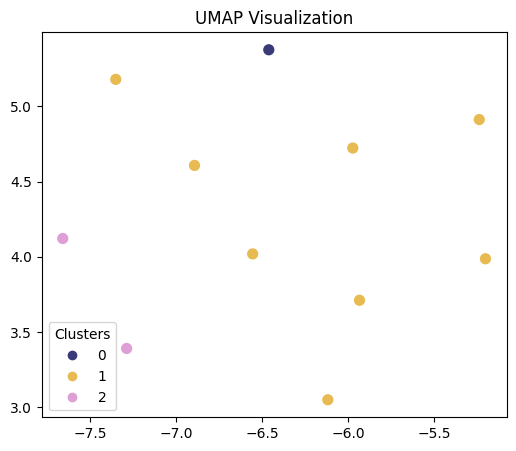

In [26]:
plot_umap_clusters(X,kmeans_bow_labels)

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


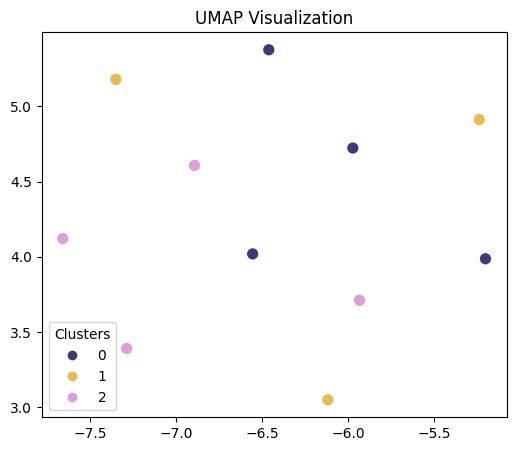

In [27]:
plot_umap_clusters(X,kmeans_emb_labels)

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


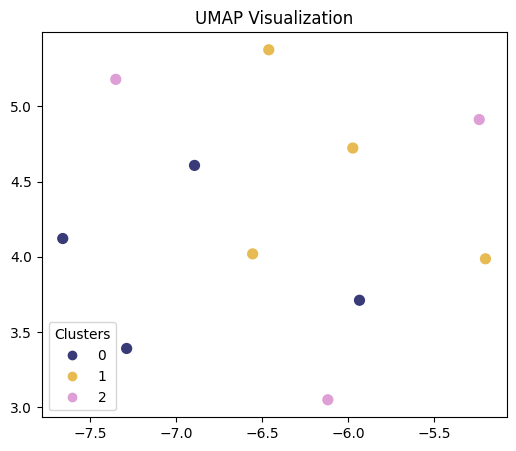

In [28]:
plot_umap_clusters(X,dbscan_emb_labels)

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


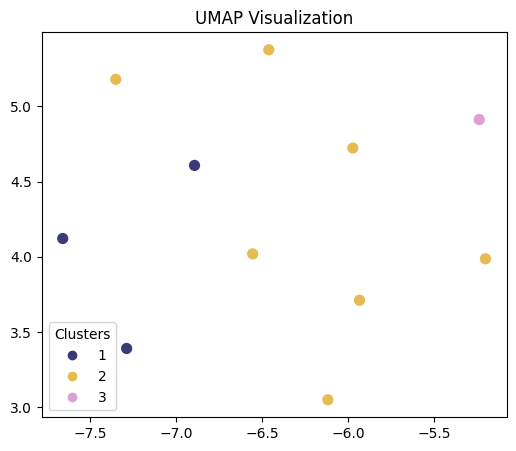

In [29]:
plot_umap_clusters(X,hier_emb_labels)

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 2: [Food.com](https://www.food.com/) recipes 
<hr>

Now that we have applied document clustering on a toy corpus, let's move to a more realistic corpus. 

In the lecture, we worked on an activity of manually clustering food items and discussed challenges associated with it. We also applied different clustering algorithms to cluster food images. We'll continue this theme of clustering food items in this lab. But instead of images we will cluster textual description of food items, i.e., recipe names.   

In this assignment, we will work with a sample of [Kaggle's Food.com recipes corpus](https://www.kaggle.com/shuyangli94/food-com-recipes-and-user-interactions). This corpus contains 180K+ recipes and 700K+ recipe reviews. In this lab, we'll only focus on recipes and **not** on reviews. The recipes are present in `RAW_recipes.csv`. Our goal is to find categories or groupings of recipes from this corpus based on their names. 

**Your tasks:**

- Download [`RAW_recipes.csv`](https://www.kaggle.com/shuyangli94/food-com-recipes-and-user-interactions?select=RAW_recipes.csv) and put it under the `data` directory in the homework folder. 
- Run the code below. The dataset is quite large, and in this assignment, for speed, you will work with a sample of the dataset. The function `get_recipes_sample` below carries out some preliminary preprocessing and returns a sample of the recipes with most frequent tags. 

> *Note: Depending upon the capacity of your computer, feel free to increase or decrease the size of this sample by changing the value for `n_tags`. If you decide to go with a different value of `n_tags`, state it clearly in Exercise 2.1 so that the grader knows about it.* 

In [30]:
orig_recipes_df = pd.read_csv("data/RAW_recipes.csv")
orig_recipes_df.shape

(231637, 12)

In [31]:
def get_recipes_sample(orig_recipes_df, n_tags=300, min_len=5):
    orig_recipes_df = orig_recipes_df.dropna()  # Remove rows with NaNs.
    orig_recipes_df = orig_recipes_df.drop_duplicates(
        "name"
    )  # Remove rows with duplicate names.
    # Remove rows where recipe names are too short (< 5 characters).
    orig_recipes_df = orig_recipes_df[orig_recipes_df["name"].apply(len) >= min_len]
    # Only consider the rows where tags are one of the most frequent n tags.
    first_n = orig_recipes_df["tags"].value_counts()[0:n_tags].index.tolist()
    recipes_df = orig_recipes_df[orig_recipes_df["tags"].isin(first_n)]
    return recipes_df

In [32]:
recipes_df = get_recipes_sample(orig_recipes_df)
recipes_df.shape

(9100, 12)

In [33]:
recipes_df["name"]

42        i yam what i yam  muffins    
101       to your health  muffins      
129       250 00 chocolate chip cookies
138       lplermagronen                
163       california roll   salad      
                   ...                 
231514    zucchini blueberry bread     
231539    zucchini parmesan pancakes   
231547    zucchini salsa burgers       
231596    zuppa toscana                
231629    zydeco salad                 
Name: name, Length: 9100, dtype: object

<br><br>

**In the rest of the homework, we will use `recipes_df` above, which is a subset of the original dataset.** 

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 2.1 Longest and shorter recipe names 
rubric={points:2}

**Your tasks:**

1. Print the shortest and longest recipe names (length in terms of number of characters) from `recipes_df`. If there is more than one recipe with the same shortest/longest length, store **one** of them in `shortest_recipe` and/or `longest_recipe` as a **string**.

</div>

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 2

In [34]:
shortest_recipe = None
longest_recipe = None

recipes_df['name_len'] = recipes_df['name'].str.len()

shortest_len = min(recipes_df['name_len'])
shortest_recipe = recipes_df[recipes_df['name_len']==shortest_len]['name'].tolist()[0]
print(f'Shortest recipe names: \n{shortest_recipe}')

longest_len = max(recipes_df['name_len'])
longest_recipe = recipes_df[recipes_df['name_len']==longest_len]['name'].tolist()[0]
print(f'longest recipe names: \n{longest_recipe}')

Shortest recipe names: 
bread
longest recipe names: 
baked tomatoes with a parmesan cheese crust and balsamic drizzle


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 2.2 More EDA
rubric={points:2}

**Your tasks:**
1. Create a word cloud for the recipe names. You can use [the `wordcloud` package](https://github.com/amueller/word_cloud) for this, which you will have to install in the course environment.
```
> conda activate cpsc330
> conda install -c conda-forge wordcloud
```

</div>

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 2

In [35]:
from wordcloud import WordCloud

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">

### 2.3 Representing recipe names
rubric={points:3}

The next step is creating a representation of recipe names. 

**Your tasks:**

1. Similar to Exercise 1, create sentence embedding representation of recipe names (`name` column in `recipes_df`).  For the rest of the homework, we'll stick to the sentence embedding representation of recipe names.


> You might have to convert the recipe names to a list (`recipes_df["name"].tolist()`) for the embedder to work
> *If you create a dataframe with sentence embedding representation, set the index to `recipes_df.index` so that the indices match with the indices of the sample we are working with.*  
> **This might take a while to run.**

</div>

<div class="alert alert-warning">

Solution_2.3
    
</div>

_Points:_ 3

In [36]:
embeddings = None

embeddings = embedder.encode(recipes_df["name"].tolist())
embeddings_df = pd.DataFrame(embeddings, index=recipes_df.index)
embeddings_df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
42,0.019592,-0.088336,0.072678,-0.034575,-0.048741,-0.049801,0.175334,-0.055191,0.020301,0.019828,...,0.063293,-0.067171,0.087500,-0.061550,0.039297,-0.050147,0.027708,0.056843,0.056151,-0.122506
101,-0.000567,-0.011825,0.073199,0.058176,0.031688,-0.015428,0.168134,0.000466,0.033078,-0.013923,...,-0.012926,-0.015949,0.031315,-0.059074,0.014143,-0.047270,0.007844,0.035501,0.076061,-0.078119
129,-0.022604,0.065034,-0.033065,0.014450,-0.105039,-0.050559,0.100076,0.022929,-0.037398,0.011857,...,0.007971,-0.019165,0.004935,0.009005,0.000919,-0.040078,0.008650,-0.075781,-0.083477,-0.123240
138,-0.066915,0.025988,-0.087689,-0.006847,-0.012861,0.049035,0.035351,0.124966,-0.011697,-0.050179,...,-0.042345,-0.005794,-0.031800,0.120664,-0.057335,-0.077068,0.001653,-0.048223,0.116455,0.021789
163,-0.007068,-0.007308,-0.026629,-0.004153,-0.052810,0.011126,0.024000,-0.036993,0.023526,-0.046870,...,-0.018432,0.051918,0.036101,-0.035312,0.005817,0.101802,-0.063171,-0.007917,0.089744,0.006997


<!-- END QUESTION -->

<br><br><br><br>

## Exercise 3: Clustering recipe names
<hr>

In this exercise you'll cluster recipe names with some of the clustering algorithms we have seen in class. This will also involve making some attempts to pick reasonable hyperparameter values for each clustering method based on the quality of the resulting clusters. For example, for KMeans, you need to specify the number of clusters in advance, which is often challenging on real-world datasets. For DBSCAN, you need to pick appropriate `eps` and `min_samples`. For hierarchical clustering, you need to pick a suitable linkage criterion, distance metric, and prune the tree so that it's possible to visualize and interpret it. 

Here are some methods which may help you with picking reasonable values for the hyperparameters. 
- Visualize the Elbow plot (KMeans). 
- Visualize Silhouette plots. 
- Visualize resulting clusters using `plot_umap_clusters` function from Exercise 1. 
- Sample some recipes from each cluster, manually inspect whether there are coherent semantic themes. (For this, you may use the function `print_clusters` given below.) 
        
> You may use the [`yellowbrick`](https://www.scikit-yb.org/en/latest/) package for visualizing the Elbow plot and the Silhouette plots. You can intall it with

```conda install -c districtdatalabs yellowbrick```

**Note that the process of picking reasonable hyperparameter values will be exploratory, iterative, and will involve manual inspection and judgment, as there is no ground truth to verify how well the model is doing. In your solutions, please do not include everything you try. Only present the results of the most informative trials. Add a narrative to your answer so that it's easy for the grader to follow your choices and reasoning.** 

In [37]:
def print_clusters(recipes_df, cluster_labels, n_recipes=10, replace=False, random_state=None):
    """
    Given recipes_df containing recipe names and cluster assignment (labels), 
    sample and print n_recipes recipes per cluster. 

    Parameters
    -----------
    recipe_df : pandas dataframe 
        recipes dataframe containing recipe names in the "name" column
    cluster_labels : ndarray or a list
        cluster labels for each row in recipes_df 
    n_recipes : int
        number of examples to sample from each cluster
    replace: bool
        replace flag to pass to the sampling of recipe names

    Returns
    -----------
    None
    """    
    
    grouped = (
        pd.DataFrame(
            {
                "name": recipes_df["name"],
                "cluster_label": cluster_labels,
            }
        )
        .sort_values("cluster_label")
        .groupby("cluster_label")    
    )
    
    for name, group in grouped:
        print(f"Cluster {name}")        
        print(("----------").format(""))        
        print("\n".join(group.sample(n_recipes, random_state=random_state, replace=replace)['name'].tolist()))
        print("\n\n")

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.1 K-Means
rubric={points:6}

**Your tasks:**

1. Cluster recipe titles using KMeans. Make some attempts to determine the optimal number of clusters. 
2. Pick one or two best models and justify your choice.

</div>

<div class="alert alert-warning">

Solution_3.1
    
</div>

_Points:_ 6

First, I will need to find the best n_clusters value for KMeans. Using KElbowVisualizer, it returned an elbow measured at n_clusters = 13. Using this parameter to then visualize Silhouette scores. From this Silhouette score plot, each samples have a fast dropoff or non-rectangular shapes. These indicates that the parameter setting for this KMeans may not be fitting the samples well to their respective clusters. However, upon trying out n_cluster values such as 10 and 20, their resulting Silhouette plot suggest their parameter values performing worse than 13. Therefore, n_clusters=13 may be the best parameter to cluster this data set.

From ```print_clusters```, its apparent majority of the clusters are clustering well to their respective label as the samples within these cluster have common features. However, clusters 0,1 made samples that doesn't visible common features. 

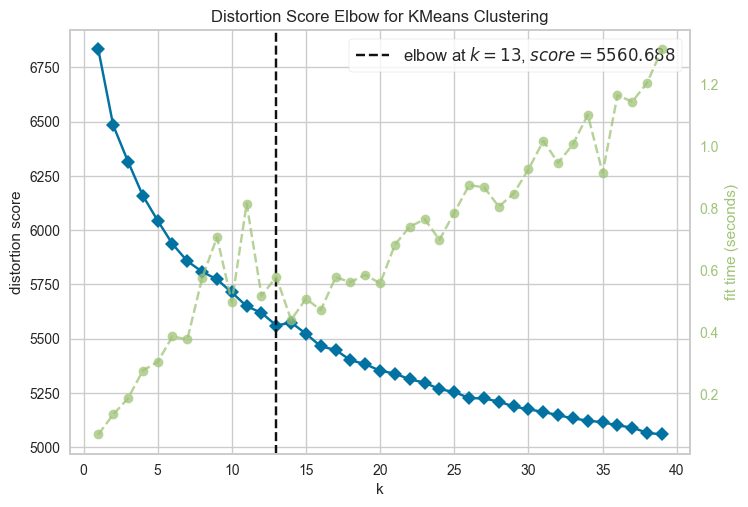

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [38]:
# following codes are referenced from lecture 14

from yellowbrick.cluster import KElbowVisualizer

recipe_kmeans = KMeans(n_init='auto',random_state=111)
visualizer = KElbowVisualizer(recipe_kmeans,k=(1,40),force_model=True)
visualizer.fit(embeddings)
visualizer.show()

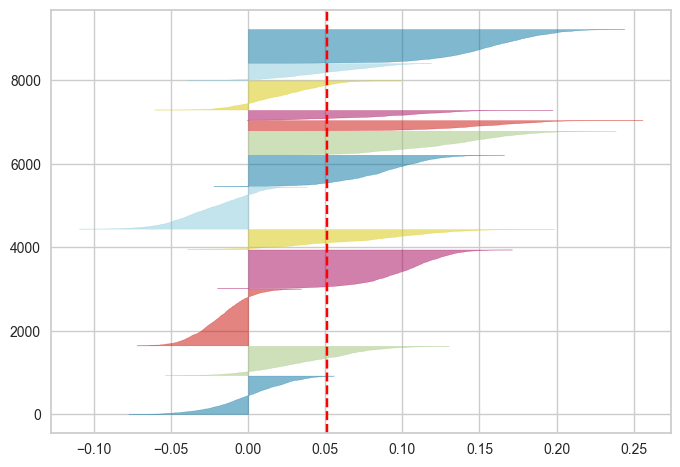

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [39]:
# following codes are referenced from lecture 14

from yellowbrick.cluster import SilhouetteVisualizer

final_recipe_kmeans = KMeans(13,n_init='auto',random_state=111)
sil_visualizer = SilhouetteVisualizer(final_recipe_kmeans,colors='yellowbrick',force_model=True)
sil_visualizer.fit(embeddings)
visualizer.show()

In [40]:
kmeans_preds = final_recipe_kmeans.fit_predict(embeddings)

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


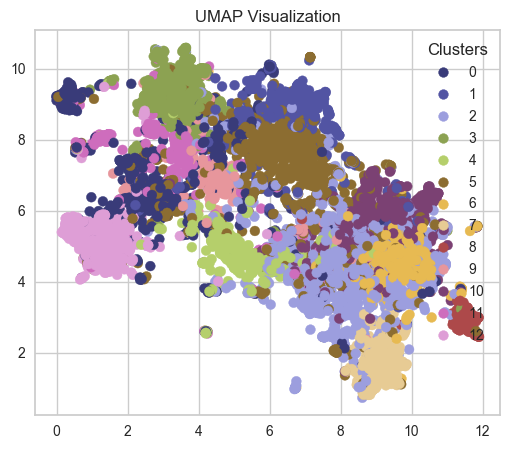

In [41]:
plot_umap_clusters(embeddings,kmeans_preds)

In [42]:
print_clusters(recipes_df,kmeans_preds,random_state=111)

Cluster 0
----------
low fat fudge brownie
golden coconut crisps
lactose free  indian curry
annabel s homemade granola
fudgy mocha toffee brownies
blueberry protein muffins or cookies
goober bars
fresh banana pudding smoothie
healthy rhubarb cinnamon muffins
carrot spice muffins fat free



Cluster 1
----------
tropical lemon cream bars
watermelon mojito
indian curry rub
mulled tea
cafe mandarin
iced creamy chai
mike s chocolate martini
smoky chipotle lime sour cream
coco snowball cocktail
finlandia midnight mango



Cluster 2
----------
summer squash casserole with nuts
scalloped potato and zucchini casserole
vietnamese style broccoli stir fry
smoked salmon dip with dill and horseradish
brussels sprouts hash
awesome roasted potatoes with sour cream dip
chicken and spinach manicotti or shells
indian carrot rice
avocado and tahini dip
spicy sweet potato   shrimp cakes



Cluster 3
----------
green tea ginger cakes
classic 7 up pound cake
beet and carrot cake
buttermilk maple spice cake


<!-- END QUESTION -->

<br><br><br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.2 DBSCAN
rubric={points:6}

**Your tasks:**

1. Cluster recipe names using `DBSCAN` with `metric="cosine"`. Make some attempts to tune the  hyperparameters `eps` and `min_samples`.

</div>

<div class="alert alert-warning">

Solution_3.2
    
</div>

_Points:_ 6

There were multiple exhaustive attempts at tuning ```eps``` and ```min_samples``` but due to how clustered the data points are, I believe that DBSCAN struggled at making meaningful clusters to be understood from.

In the attempt to fine tun the model, multiple ```eps``` and ```min_samples``` are attempted at number of clusters between 5 and 20 as I believe the number of meaningful clusters would exist between these values. However, majority of the predicted clusters either has too many outliers or has a cluster that included too many examples.

Among all tested hyperparameter attempts, ```eps=0.15``` and ```min_samples=7``` yielded the most promising clustering where majority of the clusters have samples that share common features. But there are clusters that repeated the features showed in other clusters such as cluster 1 and 9 both featuring cookies among their samples.

In [43]:
recipes_cos_dist = cosine_distances(embeddings)
recipes_cos_dist_mean = recipes_cos_dist.mean()
recipes_cos_dist_mean

np.float32(0.75085634)

In [44]:
eps_range = np.arange(0.1,0.7,0.05)
min_sample_range = np.arange(1,10)

for e in eps_range:
    for m in  min_sample_range:
        recipe_dbs = DBSCAN(eps=e,min_samples=m,n_jobs=-1,metric='cosine')
        dbs_recipe_preds = recipe_dbs.fit_predict(embeddings)
        n_recipes = len(np.unique(dbs_recipe_preds))
        if (n_recipes>=5 and n_recipes<=20):
            print(e,m,n_recipes)

0.1 4 16
0.1 5 9
0.15000000000000002 6 20
0.15000000000000002 7 11
0.15000000000000002 8 6
0.15000000000000002 9 5
0.20000000000000004 9 18
0.25000000000000006 9 20
0.30000000000000004 6 18
0.30000000000000004 7 18
0.30000000000000004 8 13
0.30000000000000004 9 13
0.3500000000000001 4 17
0.3500000000000001 5 11
0.3500000000000001 6 8
0.3500000000000001 7 6
0.3500000000000001 9 5
0.40000000000000013 3 15
0.40000000000000013 4 6
0.40000000000000013 6 5
0.45000000000000007 3 7
0.5000000000000001 2 7
0.5500000000000002 2 5
0.6500000000000001 1 8


In [45]:
final_recipe_dbs = DBSCAN(eps=0.15,min_samples=7,n_jobs=-1,metric='cosine')
final_dbs_recipe_preds = final_recipe_dbs.fit_predict(embeddings)

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


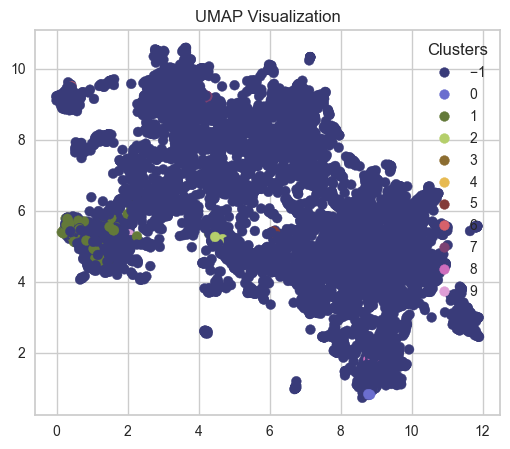

In [46]:
plot_umap_clusters(embeddings,final_dbs_recipe_preds)

In [47]:
print_clusters(recipes_df,final_dbs_recipe_preds,n_recipes=5,random_state=111)

Cluster -1
----------
herbed goat cheese sauce
cider heaven   cider and rum over ice
marshmallow fluff sponge cake
s more cupcakes
crispy buttermilk chicken



Cluster 0
----------
yogurt ranch dressing
italian salad dressing
chef salad  dressing
delicious salad dressing
ranch salad dressing



Cluster 1
----------
oatmeal peanut butter lactation cookies
simple oatmeal cookies
famous oatmeal cookies
white chip chocolate cookies my way
oatmeal pudding cookies



Cluster 2
----------
banana nut bread
you re nuts for bananas  banana nut bread
vanilla banana bread
cinnamon banana bread
chocolate banana cream bread



Cluster 3
----------
banana oatmeal snack cake
chocolate chip banana snack cake
snack cake
chocolate banana bundt cake
banana chocolate chip cake



Cluster 4
----------
cherry chocolate oat bars
chocolate   caramel oatmeal bars
chocolate oatmeal almost candy bars
chocolate chip oatmeal bars
chewy chocolate   oat bars



Cluster 5
----------
chocolate chip zucchini cake
best e

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.3 Hierarchical clustering
rubric={points:6}

**Your tasks:**

1. Try hierarchical clustering with `metric="cosine"` on this problem. Show a dendrogram by using a suitable truncation method. 
2. Create flat clusters by cutting the tree at the appropriate level. 

> *Note: Try orientation="left" of `dendrogram` for better readability of the dendrogram.*

</div>

<div class="alert alert-warning">

Solution_3.3
    
</div>

_Points:_ 6

In this clustering model, I picked the "complete" method for the hierarchical clustering as I believe having tighter clusters may yield meaningful clusters since the samples form the data set are clustered close to one another.

In order to obtain the labels, the denodrogram is plotted. I believed the best split between cluster remains between 1.2 and 1.0 cluster distances. Therefore, after observing the splitting of the clusters, I decided to "flat" cluster the clusters at 1.1 unit distance.

However, when observing both the UMAP and printed clusters, only the first three clusters contains samples that shares common features with one another. While the rest of the clusters have little to no common features.

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [10.0, 10.0, 30.0, 30.0],
  [45.0, 45.0, 55.0, 55.0],
  [65.0, 65.0, 75.0, 75.0],
  [50.0, 50.0, 70.0, 70.0],
  [20.0, 20.0, 60.0, 60.0],
  [85.0, 85.0, 95.0, 95.0],
  [105.0, 105.0, 115.0, 115.0],
  [90.0, 90.0, 110.0, 110.0],
  [125.0, 125.0, 135.0, 135.0],
  [145.0, 145.0, 155.0, 155.0],
  [130.0, 130.0, 150.0, 150.0],
  [100.0, 100.0, 140.0, 140.0],
  [40.0, 40.0, 120.0, 120.0],
  [165.0, 165.0, 175.0, 175.0],
  [185.0, 185.0, 195.0, 195.0],
  [170.0, 170.0, 190.0, 190.0],
  [205.0, 205.0, 215.0, 215.0],
  [225.0, 225.0, 235.0, 235.0],
  [210.0, 210.0, 230.0, 230.0],
  [180.0, 180.0, 220.0, 220.0],
  [245.0, 245.0, 255.0, 255.0],
  [265.0, 265.0, 275.0, 275.0],
  [250.0, 250.0, 270.0, 270.0],
  [285.0, 285.0, 295.0, 295.0],
  [305.0, 305.0, 315.0, 315.0],
  [290.0, 290.0, 310.0, 310.0],
  [260.0, 260.0, 300.0, 300.0],
  [200.0, 200.0, 280.0, 280.0],
  [80.0, 80.0, 240.0, 240.0]],
 'dcoord': [[0.0,
   np.float64(0.954

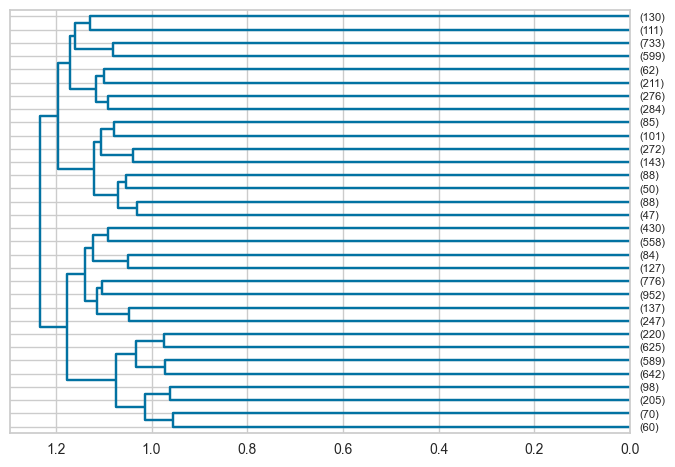

In [48]:
# Plotting of dendrogram referenced from lecture 15

recipe_link = linkage(embeddings,method="complete",metric="cosine")
dendrogram(recipe_link,p=4,truncate_mode="level",orientation="left")

In [49]:
recipe_heir_labels = fcluster(recipe_link,t=1.1,criterion="distance")
np.unique(recipe_heir_labels)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int32)

C:\Users\matth\miniforge3\envs\cpsc330\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


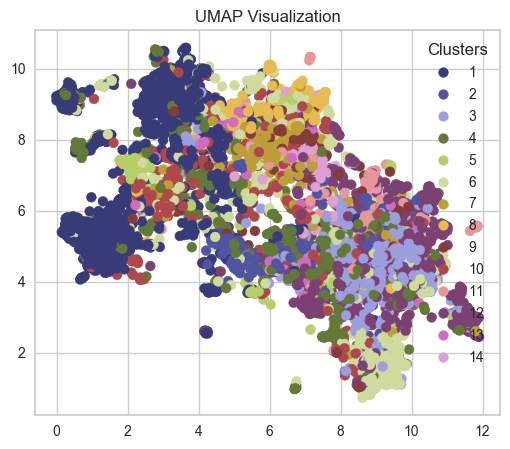

In [50]:
plot_umap_clusters(embeddings,recipe_heir_labels)

In [51]:
print_clusters(recipes_df,recipe_heir_labels,random_state=111)

Cluster 1
----------
pink frosted cookies
cherry ricotta muffins
almond bar cookies
peanut butter cup sandwich
moist  tender spice cake  gingerbread variation
giant oat cookies
pudding cookies
cheesy buttermilk drop biscuits
frosted chocolate chip cheesecake
outrageous muffins with soy flour from bob s red mill



Cluster 2
----------
banana walnut stuffed french toast
turkey meatballs and pasta in broth
herb quick bread
mincemeat nut bread
greek orzo bake
orange buckwheat bread  bread machine
banana bread   quick bread for machines
sweet  rye bread
ma s cornbread re make
real bellini s



Cluster 3
----------
stuffed garlic spinach bread
chicken artichoke dip casserole
classic tomato sauce
mama bellas tomato gravy and meatballs
thai curry chicken pizza
stuffed chicken breast in a white wine cream sauce
skillet chicken cacciatore
orange molasses glazed chicken
sarasota s salmon salad sandwich
tzipporah s moroccan chicken



Cluster 4
----------
harvest pumpkin spice bars
apple   ricott

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
### 3.4 Manual interpretation of clusters
rubric={points:6}

**Your tasks:**

1. Label the topics/themes you see in the clusters created by different clustering methods.  
2. Do you see a common theme across clusters created by different clustering methods? Do you see any differences between the clusters created by different clustering methods?

</div>

<div class="alert alert-warning">

Solution_3.4
    
</div>

_Points:_ 6

From the labels seen from the clusters made by the clustering models, labels such as "cake", "bread", "chicken", "salad", "soup", "meat", "cookies", "dressing/sauce", "snack bars" and "muffins".

A common theme across clusters created by different clustering method is how clusters are mainly grouped by common words the samples share such as "cake" in cake recipes, or "soup" in soup recipes. Between KMeans and DBScan models, they share relatively same clusters as their clusters are dominated by samples with common words.

In [52]:
recipes_df['kmeans_label'] = kmeans_preds
recipes_df['dbs_label'] = final_dbs_recipe_preds
recipes_df['hier_label'] = recipe_heir_labels

recipes_df[['name','kmeans_label','dbs_label','hier_label']].head(10)

,name,kmeans_label,dbs_label,hier_label
42,i yam what i yam muffins,0,-1,1
101,to your health muffins,0,-1,1
129,250 00 chocolate chip cookies,12,-1,1
138,lplermagronen,5,-1,9
163,california roll salad,7,-1,6
169,chef salad dressing,7,0,6
234,ma s oatmeal cake and icing,3,-1,1
262,real new york style cheesecake supreme,11,-1,1
318,aunt johnnie s pound cake,3,-1,1
337,buffalo wing mushrooms,2,-1,4


<!-- END QUESTION -->

<br><br><br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top. 

Here is a quick checklist before submitting: 

- [ ] Restart kernel, clear outputs, and run all cells from top to bottom.  
- [ ] `.ipynb` file runs without errors and contains all outputs.  
- [ ] Only `.ipynb` and required output files are uploaded (no extra files).  
- [ ] Execution numbers start at **1** and are in order.  
- [ ] If `.ipynb` is too large and doesn't render on Gradescope, also upload a PDF/HTML version.  
- [ ] Reviewed the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions).

![](img/eva-well-done.png)